In [6]:
import pandas as pd
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("chicago/chicago-transit-authority-cta-data")

path = Path(path)

print("Path to dataset files:", path)

df = pd.read_csv(path / "cta-ridership-daily-boarding-totals.csv",parse_dates=["service_date"])

df.columns= ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total",axis=1)
df = df.drop_duplicates()
df.head()

Using Colab cache for faster access to the 'chicago-transit-authority-cta-data' dataset.
Path to dataset files: /kaggle/input/chicago-transit-authority-cta-data


,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


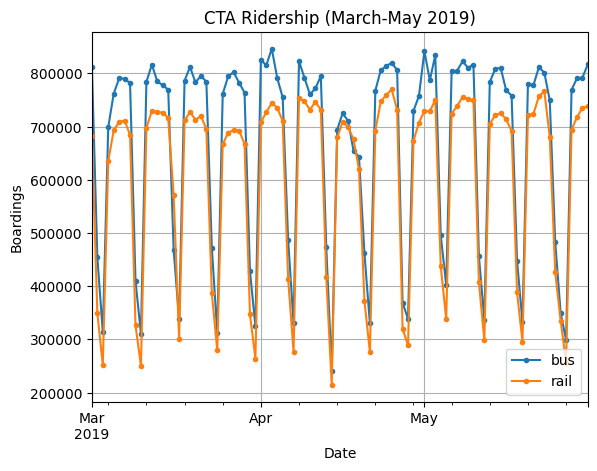

In [10]:
import matplotlib.pyplot as plt
df["2019-03":"2019-05"].plot(grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
plt.show()  

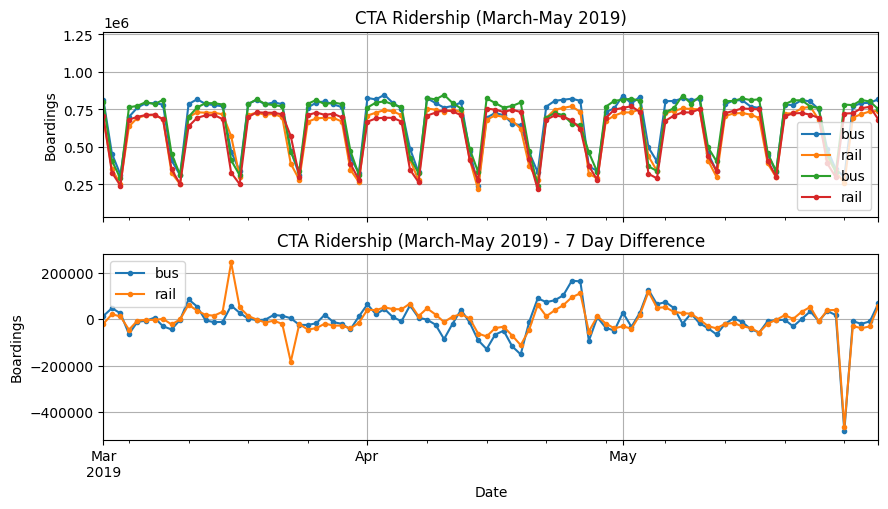

In [11]:
#Differencing
diff_7 = df[["bus","rail"]].diff(7)["2019-03":"2019-05"]
fig,axs = plt.subplots(2,1,sharex=True,figsize=(10,6))
df.plot(ax=axs[0],grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
df.shift(7).plot(ax=axs[0],grid=True,marker='.', title="CTA Ridership (March-May 2019)", ylabel="Boardings", xlabel="Date")
diff_7.plot(ax=axs[1],grid=True,marker='.', title="CTA Ridership (March-May 2019) - 7 Day Difference", ylabel="Boardings", xlabel="Date")
plt.show()

In [12]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [13]:
diff_7.abs().mean()

,0
bus,43915.608696
rail,42143.271739


In [15]:
target = df[["bus","rail"]]["2019-03":"2019-05"]
(diff_7/target).abs().mean()

,0
bus,0.082938
rail,0.089948
